<img src="../assets/ga-logo.png" style="float: left; margin: 20px; height: 55px">

# K-Means Clustering with Seeds Data

---

In [2]:
%matplotlib inline 

import pandas as pd
import numpy as np
from sklearn import cluster
from sklearn import metrics
from sklearn.metrics import pairwise_distances
import matplotlib.pyplot as plt
import matplotlib
matplotlib.style.use('ggplot') 

import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, normalize
from sklearn.decomposition import PCA

### 1. Import the data

In [3]:
df = pd.read_csv("seeds.csv")

In [4]:
# A:
df.head()

,area,perimeter,compactness,length,width,asymmetry_coeff,groove_length,species
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1


### 2. Do some EDA of relationships between features.

In [5]:
df.columns

Index(['area', 'perimeter', 'compactness', 'length', 'width',
       'asymmetry_coeff', 'groove_length', 'species'],
      dtype='object')

In [6]:
df.dtypes

area               float64
perimeter          float64
compactness        float64
length             float64
width              float64
asymmetry_coeff    float64
groove_length      float64
species              int64
dtype: object

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   area             210 non-null    float64
 1   perimeter        210 non-null    float64
 2   compactness      210 non-null    float64
 3   length           210 non-null    float64
 4   width            210 non-null    float64
 5   asymmetry_coeff  210 non-null    float64
 6   groove_length    210 non-null    float64
 7   species          210 non-null    int64  
dtypes: float64(7), int64(1)
memory usage: 13.3 KB


In [8]:
df.shape

(210, 8)

In [9]:
df.describe()

,area,perimeter,compactness,length,width,asymmetry_coeff,groove_length,species
count,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000
mean,14.847524,14.559286,0.870999,5.628533,3.258605,3.700201,5.408071,2.000000
std,2.909699,1.305959,0.023629,0.443063,0.377714,1.503557,0.491480,0.818448
min,10.590000,12.410000,0.808100,4.899000,2.630000,0.765100,4.519000,1.000000
25%,12.270000,13.450000,0.856900,5.262250,2.944000,2.561500,5.045000,1.000000
50%,14.355000,14.320000,0.873450,5.523500,3.237000,3.599000,5.223000,2.000000
75%,17.305000,15.715000,0.887775,5.979750,3.561750,4.768750,5.877000,3.000000
max,21.180000,17.250000,0.918300,6.675000,4.033000,8.456000,6.550000,3.000000


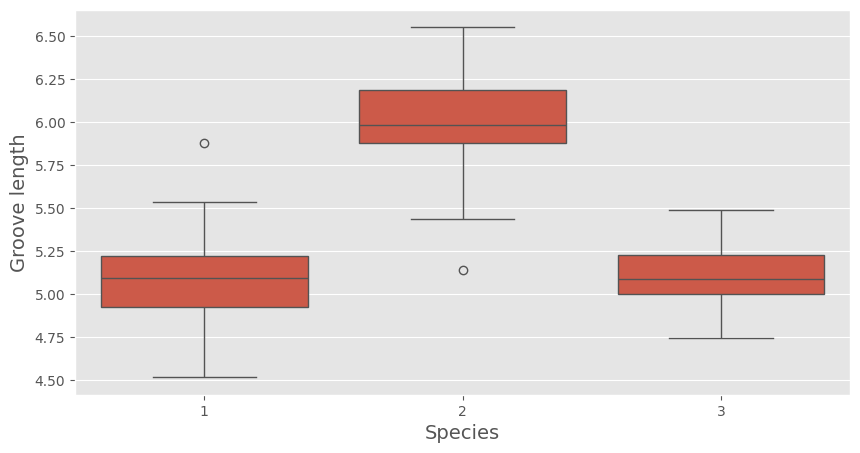

In [10]:
# Plot the Data to see the distributions/relationships
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x='species', y='groove_length')
plt.xlabel("Species", fontsize=14)
plt.ylabel("Groove length", fontsize=14)
plt.show()

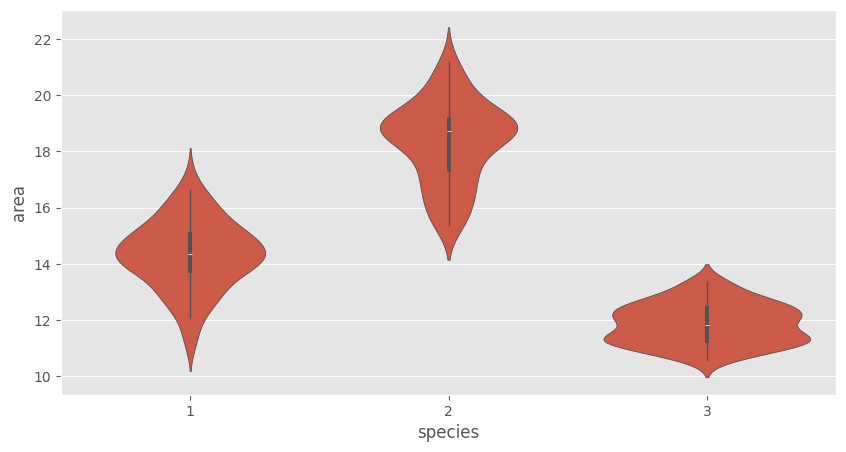

In [11]:
plt.figure(figsize=(10,5))
sns.violinplot(data=df, x='species', y='area')
plt.show()

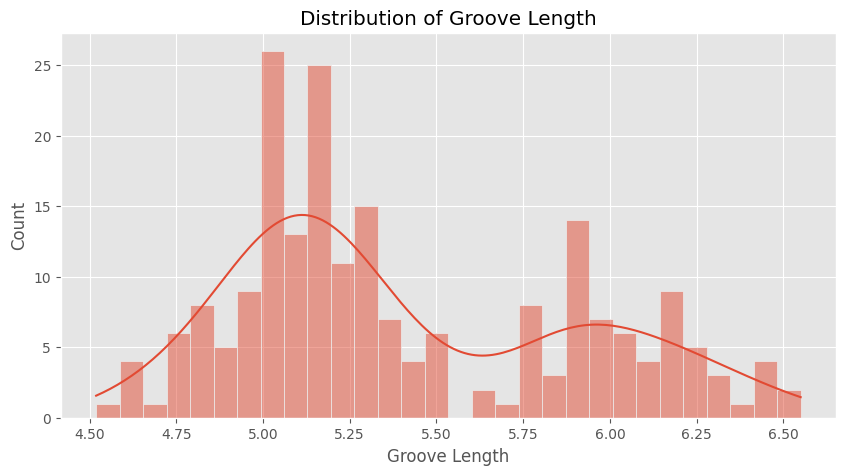

In [12]:
plt.figure(figsize=(10,5))
sns.histplot(df['groove_length'], kde=True, bins=30)
plt.xlabel('Groove Length')
plt.title('Distribution of Groove Length')
plt.show()

In [13]:
# Look at the real species labels.
df['species'].value_counts()

species
1    70
2    70
3    70
Name: count, dtype: int64

Remember, clustering is a unsupervised learning method so known classes will never be a thing.  In this situation we can see that the `perimiter` vs. `groove_length` is a good visualization to view the proper classes class, and we can use later to compare the results of clustering to a true value.

### 3. Prepare the data for clustering

1. Remove the `species` column. We will see if the clusters from K-Means end up like the actual species.
2. Put the features on the same scale.

In [14]:
# A:
## dropping species column
n_df = df.drop(columns=['species'])

In [15]:
n_df.head()

,area,perimeter,compactness,length,width,asymmetry_coeff,groove_length
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175


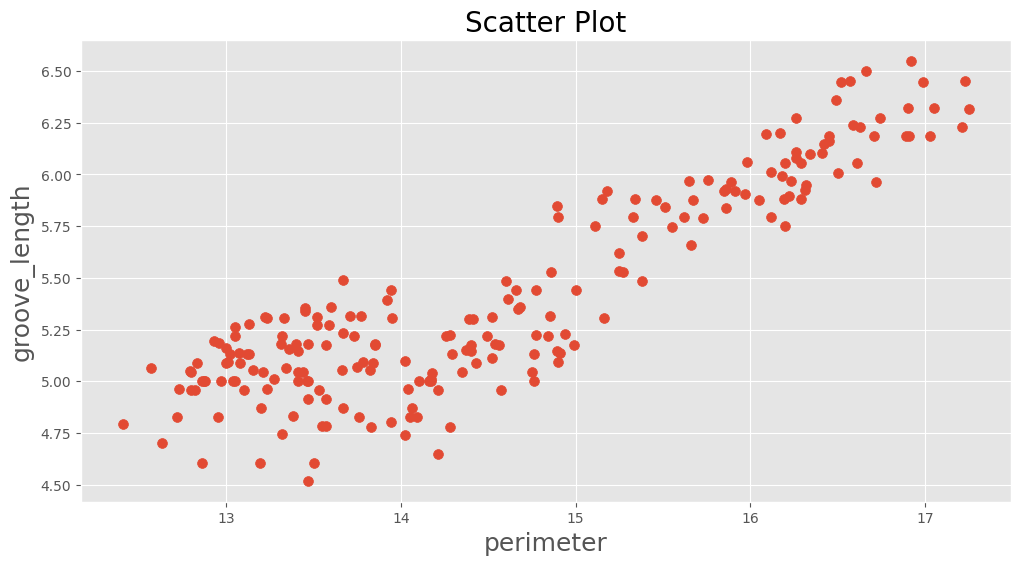

In [16]:
plt.figure(figsize=(12, 6))
plt.scatter(n_df['perimeter'], n_df['groove_length'], s=50)

plt.xlabel('perimeter', fontsize=18)
plt.ylabel('groove_length', fontsize=18)
plt.title('Scatter Plot', fontsize=20)

plt.show()

### 4. Clustering with K-Means

- Cluster the data to our our target groups.
- We know that there are 3 actual classes. However, in an actual situation in which we used clustering we would have no idea. Lets initally try using the default K for `KMeans`(8).

In [17]:
from sklearn.cluster import KMeans
X = n_df[['perimeter', 'groove_length']]
sc =StandardScaler()
X_scaled = sc.fit_transform(X)

In [18]:
km = KMeans(n_clusters=8, random_state=22)
km.fit(X_scaled)

KMeans(random_state=22)

### 5. Get the labels and centroids for out first clustering model.

In [19]:
# A:
km.labels_

array([0, 3, 3, 3, 0, 3, 0, 3, 7, 7, 0, 3, 3, 3, 3, 3, 3, 0, 3, 1, 0, 0,
       0, 1, 0, 0, 3, 3, 3, 3, 3, 0, 0, 3, 0, 0, 7, 7, 0, 3, 4, 4, 1, 7,
       0, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 0, 1, 1, 1, 1, 3, 1, 1,
       0, 0, 0, 3, 5, 5, 7, 2, 7, 7, 5, 6, 6, 7, 7, 5, 6, 6, 2, 2, 2, 6,
       6, 6, 6, 2, 2, 5, 6, 5, 2, 6, 2, 2, 7, 5, 2, 2, 2, 5, 2, 5, 6, 5,
       5, 2, 5, 2, 6, 2, 5, 2, 5, 6, 6, 5, 7, 5, 0, 5, 2, 5, 6, 7, 5, 5,
       7, 7, 7, 0, 5, 7, 7, 7, 4, 4, 4, 4, 4, 4, 4, 1, 4, 4, 4, 4, 4, 1,
       4, 4, 1, 4, 4, 4, 4, 4, 1, 4, 1, 1, 4, 4, 4, 1, 4, 1, 1, 1, 4, 1,
       1, 1, 1, 4, 1, 4, 4, 4, 4, 4, 4, 1, 1, 1, 1, 1, 4, 1, 1, 1, 1, 3,
       4, 1, 1, 1, 1, 1, 1, 1, 1, 3, 1, 1])

In [20]:
km.cluster_centers_

array([[ 0.06776708, -0.35904125],
       [-1.10918721, -0.98068556],
       [ 1.41966415,  1.47216876],
       [-0.40686764, -0.96329358],
       [-0.87126138, -0.32437438],
       [ 1.12884773,  1.03865521],
       [ 1.789453  ,  1.91864465],
       [ 0.57338343,  0.6677469 ]])

### 6. Compute the silouette score and visually examine the results of the 8 clusters. 

_(pairplot with hue)_

In [21]:
from sklearn.metrics import silhouette_score

# A:
silhouette_score(X_scaled, km.labels_)

0.3757645763797557

### 7. Repeat steps #4 and #6 with two selected or random K values and compare the results to the k=8 model.

In [22]:
import random

rand1, rand2 = random.randint(1,25), random.randint(1,25)
print(f"first random number {rand1}")
print(f"first random number {rand2}")

first random number 22
first random number 12


In [23]:
# A:
score = []
km = KMeans(n_clusters=rand1, random_state=42)
km.fit(X_scaled)

score1 = silhouette_score(X_scaled, km.labels_)
score.append({'k_values': rand1, 'score': score1})

In [24]:
km = KMeans(n_clusters=rand2, random_state=42)
km.fit(X_scaled)

score2 = silhouette_score(X_scaled, km.labels_)
score.append({'k_values': rand2, 'score': score2})
print(score)

[{'k_values': 22, 'score': 0.3543649786168947}, {'k_values': 12, 'score': 0.36698800543864807}]


### 8. Build a function to find the optimal number of clusters using silhouette score as the criteria.
1. Function should accept a range and a dataframe as arguments
2. Returns the optimal K value, associate silhoutte and scaling method.
3. Your function should also consider the scaled results of the data. 
    - `normalize`, `StandardScaler`, `MinMaxScaler`


Once you have found the optimal K and version of the data, visualize the clusters.





In [25]:
# A:
def find_optimal(df, k_range, random_state=42, show_plots=True, return_results=True):
    numeric_df = df.select_dtypes(include=[np.number]).copy()
    if numeric_df.shape[1] == 0:
        raise ValueError("Data must contain at least one numeric column.")

    scalers = {
        'none': lambda X: X.values,
        'normalize': lambda X: normalize(X.values),
        'standard': lambda X: StandardScaler().fit_transform(X.values),
        'minmax': lambda X: MinMaxScaler().fit_transform(X.values)
    }

    records = []
    best = {'score': -1, 'k': None, 'scaler': None, 'labels': None, 'scaled': None}
    
    for scaler_name, scaler_fn in scalers.items():
        try:
            X_scaled = scaler_fn(numeric_df)
        except Exception as e:
            print(f"Skipping scaler {scaler_name} due to error: {e}")
            continue

        for k in k_range:
            if k < 2 or k >= X_scaled.shape[0]:
                records.append({'scaler': scaler_name, 'k': k, 'silhouette': np.nan})
                continue

            try:
                km = KMeans(n_clusters=k, random_state=random_state, n_init=5)
                labels = km.fit_predict(X_scaled)
                score = silhouette_score(X_scaled, labels)
            except Exception as e:
                score = np.nan

            records.append({'scaler': scaler_name, 'k': k, 'silhouette': score})

            if not np.isnan(score) and score > best['score']:
                best.update({'score': score, 'k': k, 'scaler': scaler_name, 'labels': labels, 'scaled': X_scaled.copy()})
    
    results_df = pd.DataFrame.from_records(records)
    
    result = {
        'best_k': best['k'],
        'best_scaler': best['scaler'],
        'best_score': best['score'],
        'best_labels': best['labels'],
        'best_scaled_data': best['scaled'],
        'results_df': results_df
    }
    
    if show_plots:
        for scaler_name in results_df['scaler'].unique():
            sub = results_df[results_df['scaler'] == scaler_name].sort_values('k')
            plt.figure(figsize=(6,4))
            plt.plot(sub['k'], sub['silhouette'], marker='o')
            plt.title(f"Silhouette vs k — scaler: {scaler_name}")
            plt.xlabel("k (number of clusters)")
            plt.ylabel("Silhouette score")
            plt.grid(True)
            plt.show()
        
        if result['best_labels'] is not None:
            pca = PCA(n_components=2, random_state=random_state)
            two_d = pca.fit_transform(result['best_scaled_data'])
            plt.figure(figsize=(6,5))
            plt.scatter(two_d[:,0], two_d[:,1], c=result['best_labels'])
            plt.title(f"PCA (2D) scatter — best_k={result['best_k']}, scaler={result['best_scaler']}, silhouette={result['best_score']:.3f}")
            plt.xlabel("PC1")
            plt.ylabel("PC2")
            plt.grid(True)
            plt.show()
        else:
            print("No valid clustering was found to visualize.")
    
    if return_results:
        return result

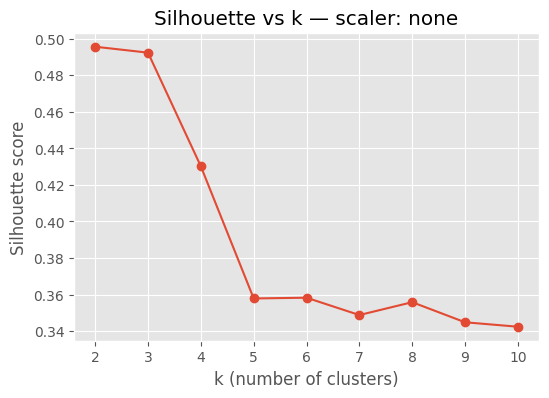

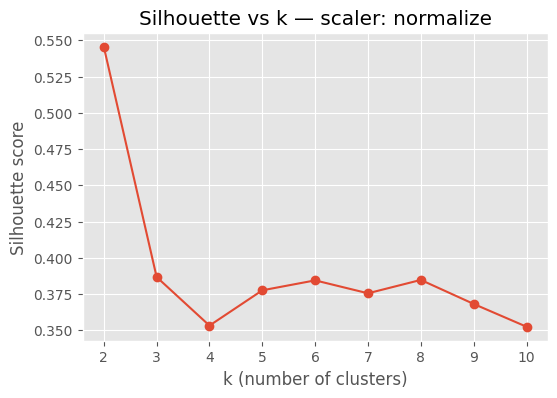

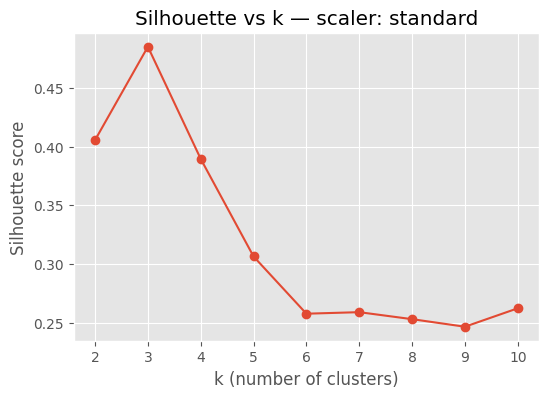

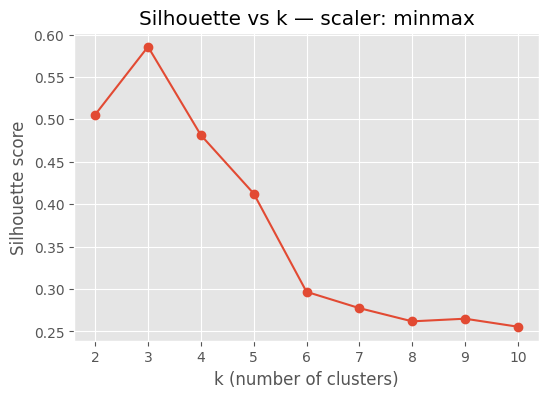

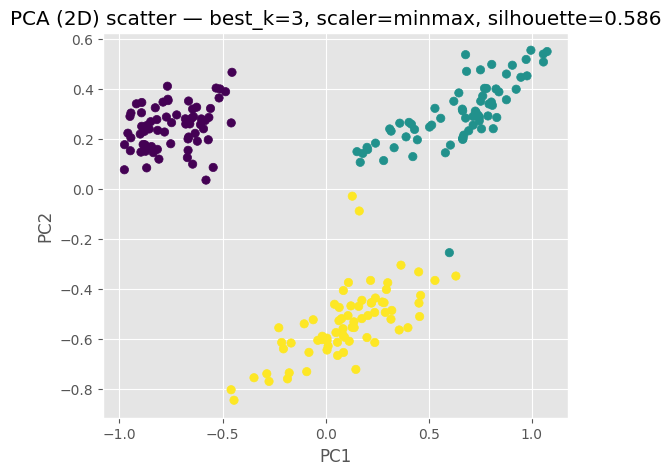

{'best_k': 3,
 'best_scaler': 'minmax',
 'best_score': 0.5856586668903163,
 'best_labels': array([2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 2, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
 'best_scaled_data': array([[0.44098206, 0.50206612, 0.5707804 , ..., 0.18930164, 0.34515017,
         0.        ],
        [0.40509915, 0.44628099, 0.66243194, ..., 0.03288302, 0.21516494,
        

In [26]:
find_optimal(df, range(2,11))